# 1.6 - Tropical Atlantic sub-clustering (two-stage)

The eastward tropical / retroflection pathway is only ~1% of the particles, so a
single global k-means (notebook 1.5) can never give it more than 2-3 clusters -
k-means spends clusters where the data is dense. **Fix: isolate the tropical
subset first, then cluster only that subset with its own k.** Every cluster here
is a real tropical sub-pathway.

**Tune** the gate (`LON_GATE`, `LAT_BAND`) and `K_TROPICAL` at the top, then run
top to bottom. Same eyeball-and-merge workflow as 1.5:
1. Gate the eastern/tropical trajectories.
2. Fit k-means on that subset only.
3. Grid + one-map of the sub-clusters.
4. Hand-assign group letters -> paste `GROUP_MAP` / `GROUP_NAMES`.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import config as C
import pipeline as P

# --- TUNE ME -----------------------------------------------------------------
K_TROPICAL = 20             # clusters for the tropical subset only

# Gate: which trajectories count as "tropical Atlantic" (by day-180 endpoint).
LON_GATE = -42.0               # keep endpoints EAST of this longitude
LAT_BAND = (-2, 15.0)         # ... and within this latitude band (N)

# Per-day weights (retroflection lives at day 30-50). None -> config.DAY_WEIGHTS.
DAY_WEIGHTS = {30: 2.0, 50: 2.0, 100: 1.0, 150: 1.0, 180: 2.0}
# -----------------------------------------------------------------------------

_wd = DAY_WEIGHTS if DAY_WEIGHTS is not None else C.DAY_WEIGHTS
W   = np.array([np.sqrt(_wd[d]) for d in C.DAYS for _ in range(2)])
print("days:", C.DAYS, "| K_TROPICAL:", K_TROPICAL, "| weights:", _wd)
print(f"gate: lon_180 > {LON_GATE} and {LAT_BAND[0]} < lat_180 < {LAT_BAND[1]}")

days: [30, 50, 100, 150, 180] | K_TROPICAL: 20 | weights: {30: 2.0, 50: 2.0, 100: 1.0, 150: 1.0, 180: 2.0}
gate: lon_180 > -42.0 and -2 < lat_180 < 15.0


## Gate the tropical subset
Keep only `complete` trajectories whose **day-180 endpoint** lands in the eastern
tropical box. (For a more physical gate you could instead require the path to
enter a retroflection box ~5-8N, 44-48W; the endpoint gate is the simple version.)

In [3]:
features = pd.read_parquet(C.FEATURES_FILE)
complete = features[features.status == "complete"]

sel = ((complete.lon_180 > LON_GATE)
       & (complete.lat_180 > LAT_BAND[0]) & (complete.lat_180 < LAT_BAND[1]))
trop = complete[sel].reset_index(drop=True)
print(f"tropical subset: {len(trop):,} of {len(complete):,} complete "
      f"({100*len(trop)/len(complete):.2f}%)")

tropical subset: 120,315 of 15,546,742 complete (0.77%)


## Fit k-means on the tropical subset
Small subset -> plain `KMeans`. Standardize each day, apply the per-day weights,
fit. Change `K_TROPICAL` / `DAY_WEIGHTS` above and re-run to re-cluster.

In [4]:
K = K_TROPICAL
X_raw  = P.build_feature_matrix(trop)                    # raw degrees
scaler = StandardScaler().fit(X_raw)
X_sub  = scaler.transform(X_raw) * W                     # standardized + weighted

km = KMeans(n_clusters=K, random_state=C.RANDOM_STATE, n_init=10)
labels = km.fit_predict(X_sub)
sizes  = np.bincount(labels, minlength=K)

cent_deg = P.centroids_to_degrees(km.cluster_centers_ / W, scaler)   # [lat,lon per day]
print(f"fit k={K} on {len(trop):,} tropical trajectories | sizes {sizes.min()}..{sizes.max()}")

fit k=20 on 120,315 tropical trajectories | sizes 256..10567


## Cheap coastline
Coarsest Natural Earth coastline (110 m) loaded once as plain (lon, lat) segments
-> map backdrop without a cartopy GeoAxes per panel.

In [5]:
import cartopy.feature as cfeature
lon = (C.DOMAIN["lon_min"], C.DOMAIN["lon_max"])
lat = (C.DOMAIN["lat_min"], C.DOMAIN["lat_max"])

_coast = []
for geom in cfeature.COASTLINE.with_scale("110m").geometries():
    for line in getattr(geom, "geoms", [geom]):
        _coast.append((np.asarray(line.xy[0]), np.asarray(line.xy[1])))

def draw_coast(ax):
    for x, y in _coast:
        ax.plot(x, y, "-", color="0.75", lw=.4, zorder=0)
    ax.set_xlim(*lon); ax.set_ylim(*lat)
print("coastline segments:", len(_coast))

coastline segments: 134


## Stream a few FULL member trajectories per sub-cluster
Same open-each-store-once trick as notebook 04; bounded I/O
(`K x MEMBERS_PER_PANEL` paths).

In [11]:
MEMBERS_PER_PANEL = 20
N_IO_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", 16))
stores = C.list_stores()

memdf = pd.DataFrame({"trajectory_id": trop.trajectory_id.to_numpy(), "lab": labels})
pick = (memdf.groupby("lab", group_keys=False)
              .apply(lambda d: d.sample(min(MEMBERS_PER_PANEL, len(d)),
                                        random_state=C.RANDOM_STATE)))
pick["store_index"] = pick.trajectory_id // C.TRAJ_PER_STORE
pick["local"]       = pick.trajectory_id %  C.TRAJ_PER_STORE

def _read_paths(si, grp):
    ds  = xr.open_zarr(stores[si])
    loc = grp.local.to_numpy()
    return grp.trajectory_id.to_numpy(), ds.lon.values[loc], ds.lat.values[loc]

res = Parallel(n_jobs=N_IO_THREADS, backend="threading")(
    delayed(_read_paths)(si, grp) for si, grp in pick.groupby("store_index"))
paths = {}
for tids, plon, plat in res:
    for j, tid in enumerate(tids):
        paths[int(tid)] = (plon[j], plat[j])
members = {c: pick.loc[pick.lab == c, "trajectory_id"].to_numpy() for c in range(K)}
print(f"streamed {len(paths):,} full trajectories from {pick.store_index.nunique()} stores")

/tmp/ipykernel_1071036/4042792590.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(MEMBERS_PER_PANEL, len(d)),


streamed 100 full trajectories from 83 stores


## The grid - one panel per sub-cluster
Grey coastline + grey full member paths + orange centroid track. The gate box is
drawn in green so you can see where the endpoints must land.

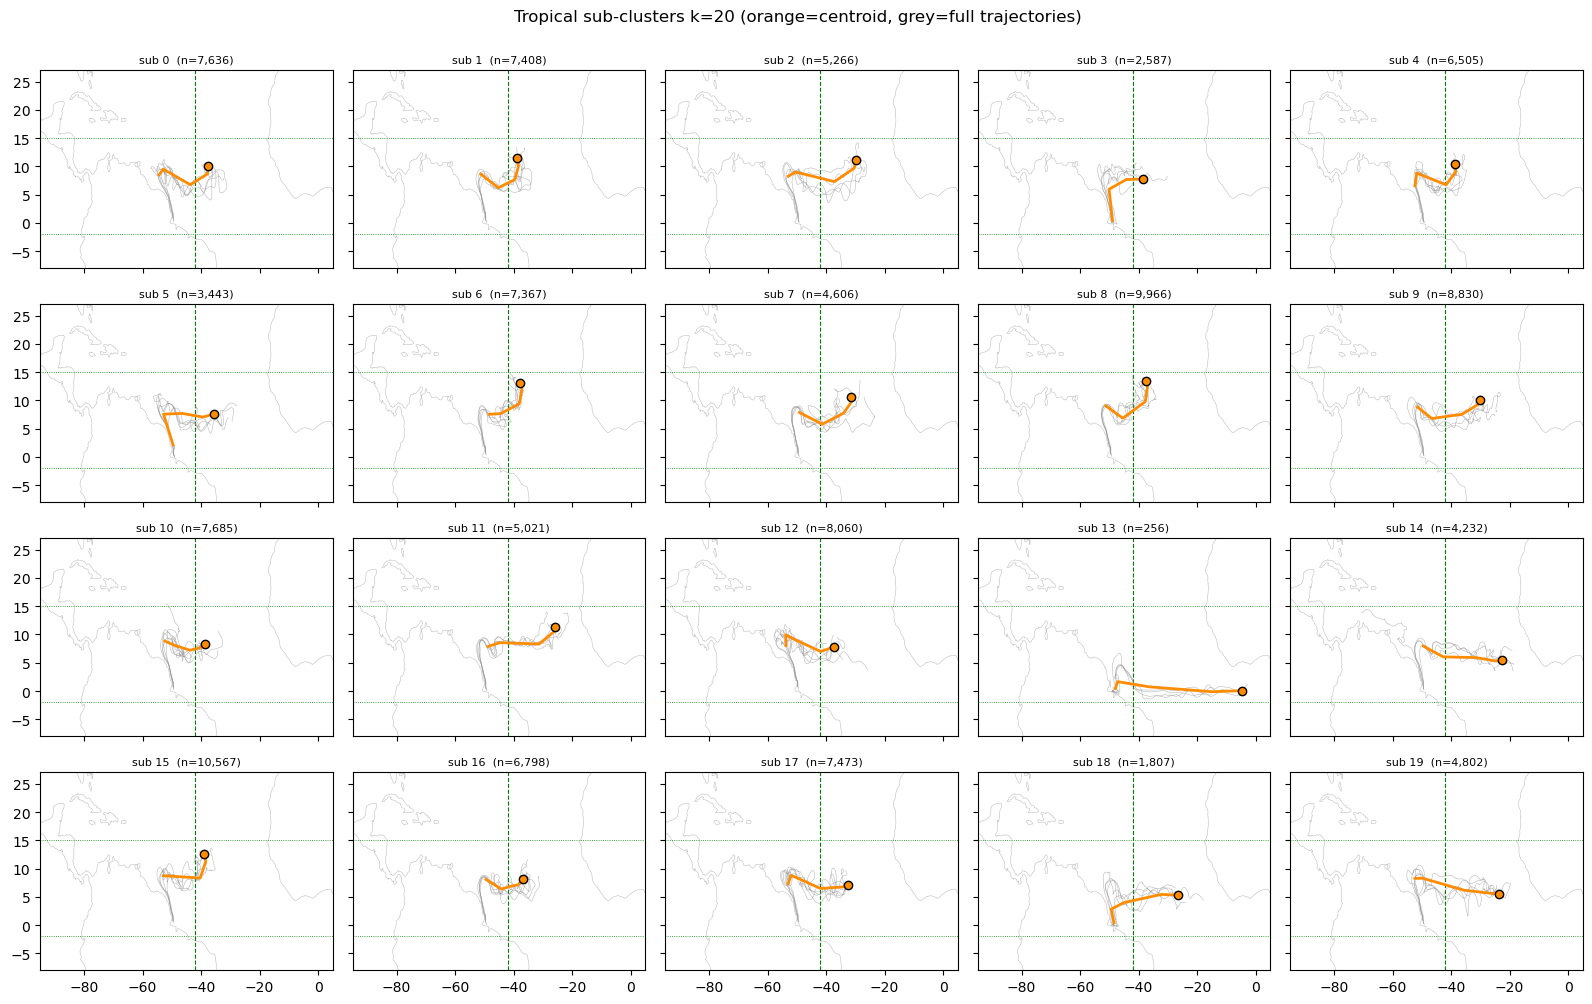

In [12]:
NCOL = 5

def draw_gate(ax):
    ax.axvline(LON_GATE, color="green", lw=.8, ls="--", zorder=1)
    ax.axhline(LAT_BAND[0], color="green", lw=.6, ls=":", zorder=1)
    ax.axhline(LAT_BAND[1], color="green", lw=.6, ls=":", zorder=1)

def draw_cluster(ax, c):
    draw_coast(ax); draw_gate(ax)
    for tid in members[c]:
        lo, la = paths[int(tid)]
        m = ~(np.isnan(lo) | np.isnan(la))
        ax.plot(lo[m], la[m], "-", color="0.55", lw=.4, alpha=.6)
    clo, cla = cent_deg[c, 1::2], cent_deg[c, 0::2]
    ax.plot(clo, cla, "-", color="darkorange", lw=2, zorder=3)
    ax.plot(clo[-1], cla[-1], "o", color="darkorange", mec="k", ms=6, zorder=4)

nrow = int(np.ceil(K / NCOL))
fig, axes = plt.subplots(nrow, NCOL, figsize=(3.2 * NCOL, 2.5 * nrow),
                         squeeze=False, sharex=True, sharey=True)
for c in range(K):
    ax = axes[c // NCOL][c % NCOL]
    draw_cluster(ax, c)
    ax.set_title(f"sub {c}  (n={sizes[c]:,})", fontsize=8)
for j in range(K, nrow * NCOL):
    axes[j // NCOL][j % NCOL].axis("off")
fig.suptitle(f"Tropical sub-clusters k={K} (orange=centroid, grey=full trajectories)", y=1.0)
fig.tight_layout(); plt.show()

## All sub-clusters on one map
Every tropical centroid track together; number = sub-cluster id at its endpoint.

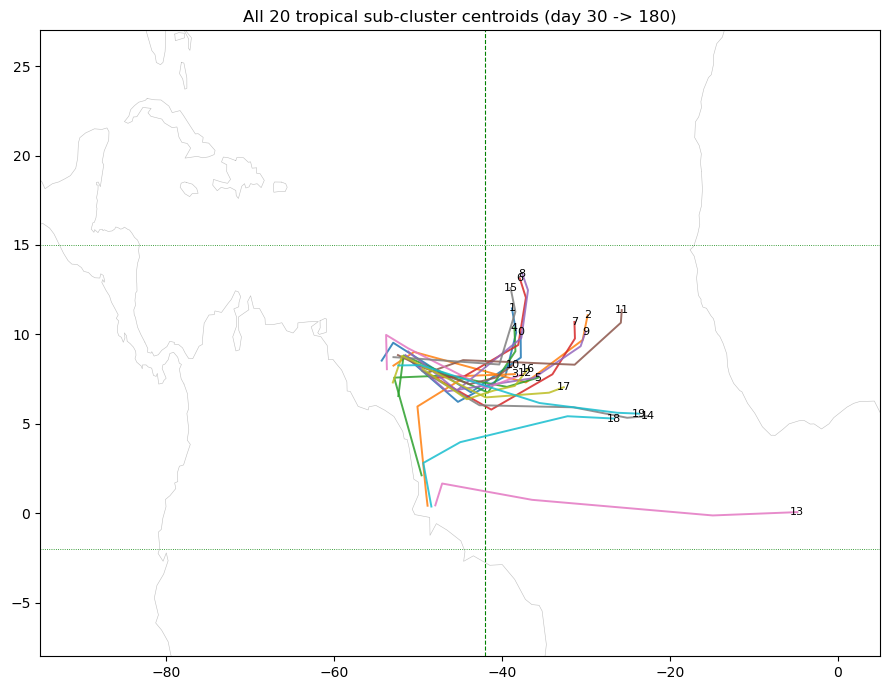

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
draw_coast(ax); draw_gate(ax)
allcmap = plt.get_cmap("tab10", K)
for c in range(K):
    lo, la = cent_deg[c, 1::2], cent_deg[c, 0::2]
    ax.plot(lo, la, "-", color=allcmap(c), lw=1.4, alpha=.85, zorder=2)
    # ax.plot(lo[-1], la[-1], "o", color=allcmap(c), mec="k", ms=5, zorder=3)
    ax.text(lo[-1], la[-1], str(c), fontsize=8, ha="center", va="center", zorder=4)
ax.set_title(f"All {K} tropical sub-cluster centroids (day {C.DAYS[0]} -> {C.DAYS[-1]})")
fig.tight_layout(); plt.show()

## Assign each sub-cluster a group letter
`ASSIGN[cluster] = "letter"`. Same letter => merged. Start all-separate; merge
sub-clusters that are the same physical pathway.

In [9]:
import string
def lbl(c):
    return string.ascii_uppercase[c] if c < 26 else f"g{c}"
ASSIGN = {c: lbl(c) for c in range(K)}

# --- merge by hand, e.g.: ---
# for c in [0, 3]:  ASSIGN[c] = "A"

ASSIGN

{0: 'A',
 1: 'B',
 2: 'C',
 3: 'D',
 4: 'E',
 5: 'F',
 6: 'G',
 7: 'H',
 8: 'I',
 9: 'J',
 10: 'K',
 11: 'L',
 12: 'M',
 13: 'N',
 14: 'O',
 15: 'P',
 16: 'Q',
 17: 'R',
 18: 'S',
 19: 'T'}

## Preview the merged groups

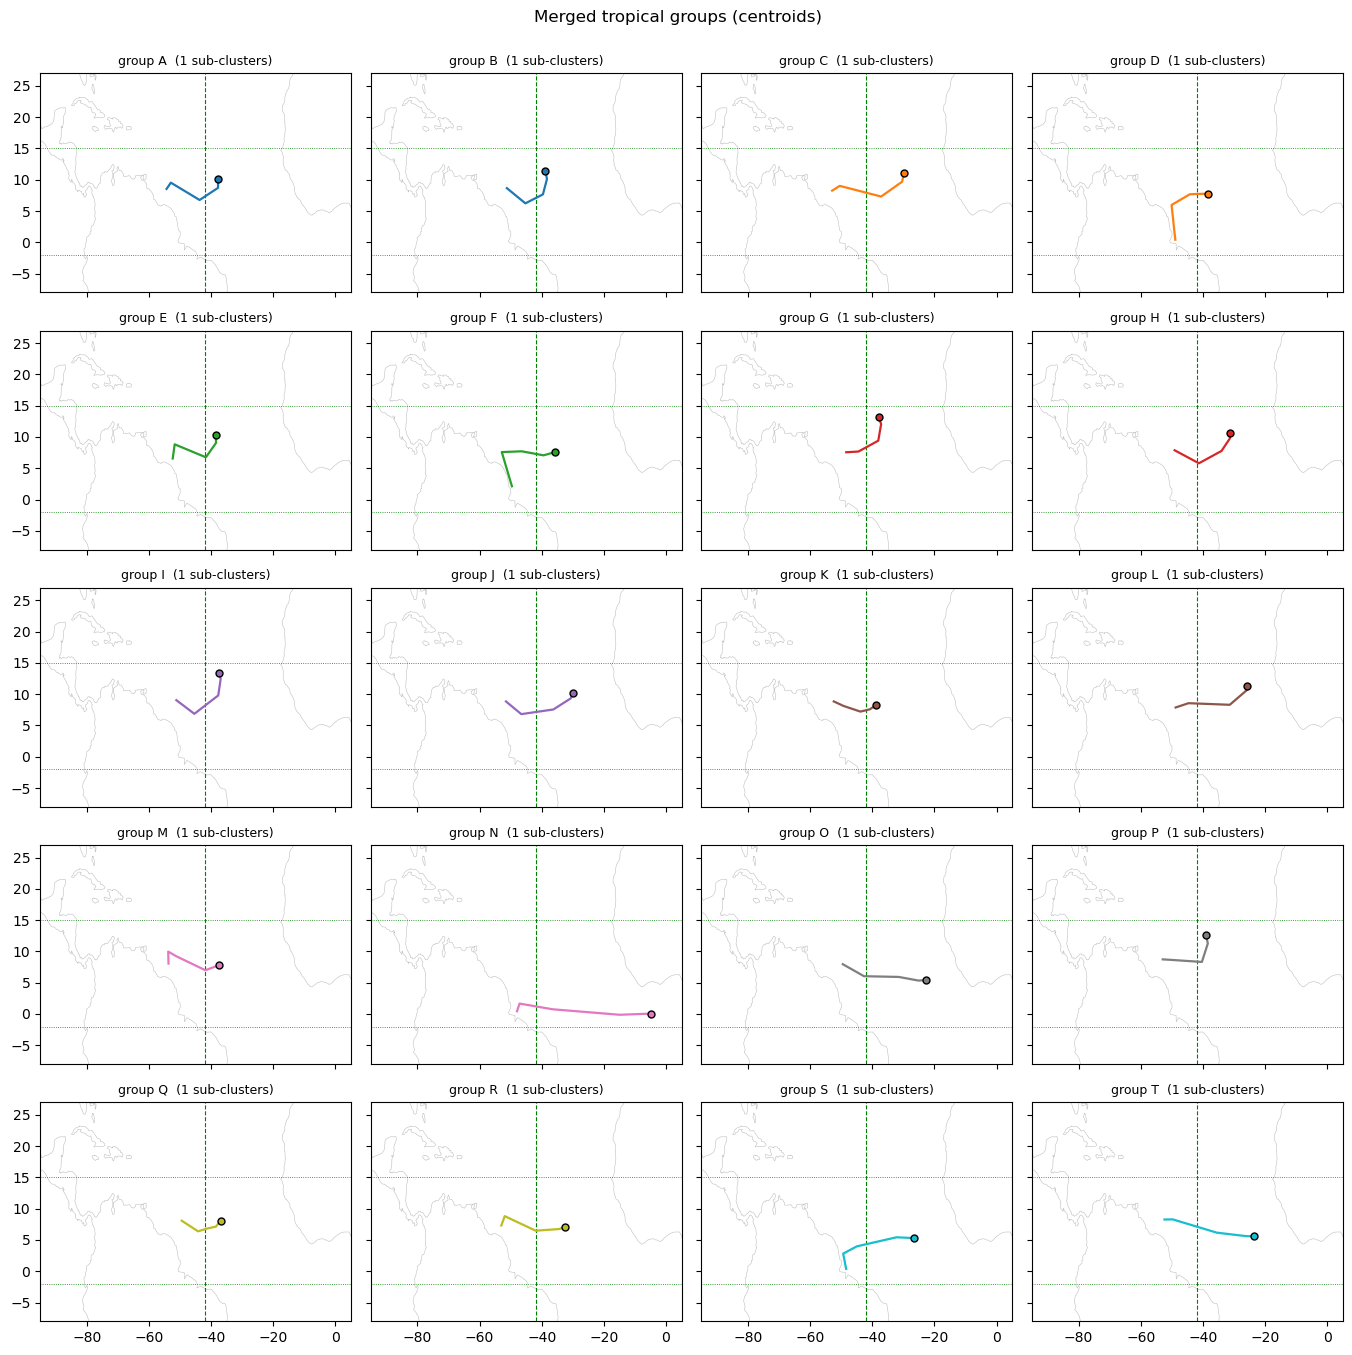

In [10]:
letters = sorted(set(ASSIGN.values()))
NCOLg = min(4, len(letters))
nrowg = int(np.ceil(len(letters) / NCOLg))
cmap  = plt.get_cmap("tab10", K)
fig, axes = plt.subplots(nrowg, NCOLg, figsize=(3.4 * NCOLg, 2.7 * nrowg),
                         squeeze=False, sharex=True, sharey=True)
for i, L in enumerate(letters):
    ax  = axes[i // NCOLg][i % NCOLg]
    draw_coast(ax); draw_gate(ax)
    mem = [c for c in range(K) if ASSIGN[c] == L]
    for c in mem:
        ax.plot(cent_deg[c, 1::2], cent_deg[c, 0::2], "-", color=cmap(c), lw=1.6)
        ax.plot(cent_deg[c, -1], cent_deg[c, -2], "o", color=cmap(c), mec="k", ms=5)
    ax.set_title(f"group {L}  ({len(mem)} sub-clusters)", fontsize=9)
for j in range(len(letters), nrowg * NCOLg):
    axes[j // NCOLg][j % NCOLg].axis("off")
fig.suptitle("Merged tropical groups (centroids)", y=1.0)
fig.tight_layout(); plt.show()

## Export -> paste into `config.py`

In [10]:
name2id     = {L: i for i, L in enumerate(letters)}
GROUP_MAP   = {c: name2id[ASSIGN[c]] for c in range(K)}
GROUP_NAMES = {i: L for L, i in name2id.items()}

print("# tropical subset gate:", f"lon_180>{LON_GATE}, lat_180 in {LAT_BAND}", "| weights:", _wd)
print("GROUP_MAP =", GROUP_MAP)
print("GROUP_NAMES =", GROUP_NAMES)
print()
for L in letters:
    print(f"  {L}: {[c for c in range(K) if ASSIGN[c] == L]}")

# tropical subset gate: lon_180>-40.0, lat_180 in (-2, 15.0) | weights: {30: 2.0, 50: 2.0, 100: 1.0, 150: 1.0, 180: 2.0}
GROUP_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 69: 69, 70: 70, 71: 71, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77, 78: 78, 79: 79, 80: 80, 81: 81, 82: 82, 83: 83, 84: 84, 85: 85, 86: 86, 87: 87, 88: 88, 89: 89, 90: 90, 91: 91, 92: 92, 93: 93, 94: 94, 95: 95, 96: 96, 97: 97, 98: 98, 99: 99}
GROUP_NAMES = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I',